# 05 - Modelo: Regresión Logística con TF-IDF Bigrama

Entrena y evalúa un clasificador **Logistic Regression** sobre la codificación
TF-IDF (uni+bigramas) generada en `02_encoding-2.ipynb`.

## Flujo
1. Cargar artefactos TF-IDF desde `02_encoding-2.ipynb`.
2. Ajustar el hiperparámetro de regularización `C` con `X_val`.
3. Re-entrenar modelo final con `X_train_tfidf` completo.
4. Evaluar **una sola vez** sobre `X_test_tfidf`.
5. Registrar en MLflow.

## Política de evaluación
| Conjunto | Uso |
|---|---|
| `X_tr` | Entrenar durante ajuste de hiperparámetros |
| `X_val` | Validar para elegir mejor `C` |
| `X_train_tfidf` | Entrenamiento final |
| `X_test_tfidf` | Evaluación final única |


## 1. Instalación e imports

In [ ]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn

In [ ]:
!pip install -q mlflow
import mlflow, mlflow.sklearn

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print('OK - Imports listos. SEED:', SEED)


OK - Imports listos. SEED: 42


## 2. Carga de artefactos TF-IDF

In [ ]:
X_tr          = load_npz('X_tr.npz')
X_val         = load_npz('X_val.npz')
X_train_tfidf = load_npz('X_train_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

y_tr    = joblib.load('y_tr.pkl')
y_val   = joblib.load('y_val.pkl')
y_train = joblib.load('y_train.pkl')
y_test  = joblib.load('y_test.pkl')

print('X_tr:          ', X_tr.shape)
print('X_val:         ', X_val.shape)
print('X_train_tfidf: ', X_train_tfidf.shape)
print('X_test_tfidf:  ', X_test_tfidf.shape)


X_tr:           (1088000, 100000)
X_val:          (272000, 100000)
X_train_tfidf:  (1360000, 100000)
X_test_tfidf:   (240000, 100000)


## 3. Regresión Logística para clasificación de texto

**Logistic Regression** es un modelo paramétrico lineal que estima la probabilidad
de cada clase mediante la función sigmoide aplicada a una combinación lineal de features.

### Ventajas sobre Naive Bayes con TF-IDF
- No asume independencia entre features.
- Aprende pesos individuales por feature, incluyendo los negativos.
- Muy eficiente con matrices sparse de alta dimensión (`solver='saga'`).

### Hiperparámetro clave: `C` (inverso de la regularización)
| Valor de `C` | Efecto |
|---|---|
| `C` pequeño (0.01) | Regularización fuerte → modelo más simple |
| `C` grande (10, 100) | Poca regularización → puede sobreajustar |

### Solvers recomendados para texto
- `saga`: el más rápido para datasets grandes con matrices sparse.
- `lbfgs`: bueno para datasets medianos.


## 4. Ajuste del hiperparámetro `C`

In [ ]:
Cs            = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
results_C     = []

for C in Cs:
    lr = LogisticRegression(
        C=C,
        solver='saga',
        max_iter=1000,
        random_state=SEED,
        n_jobs=-1
    )
    lr.fit(X_tr, y_tr)
    y_pred_val = lr.predict(X_val)
    f1         = f1_score(y_val, y_pred_val, average='macro')
    acc        = accuracy_score(y_val, y_pred_val)
    results_C.append({'C': C, 'f1_macro': round(f1, 4), 'accuracy': round(acc, 4)})
    print(f'C={C:<6} | F1 macro: {f1:.4f} | Accuracy: {acc:.4f}')

df_C      = pd.DataFrame(results_C)
best_C    = df_C.loc[df_C['f1_macro'].idxmax(), 'C']
print(f'\nMejor C: {best_C}')


C=0.01   | F1 macro: 0.7773 | Accuracy: 0.7773
C=0.1    | F1 macro: 0.8078 | Accuracy: 0.8078
C=0.5    | F1 macro: 0.8199 | Accuracy: 0.8199
C=1.0    | F1 macro: 0.8213 | Accuracy: 0.8213
C=5.0    | F1 macro: 0.8184 | Accuracy: 0.8184
C=10.0   | F1 macro: 0.8153 | Accuracy: 0.8153

Mejor C: 1.0


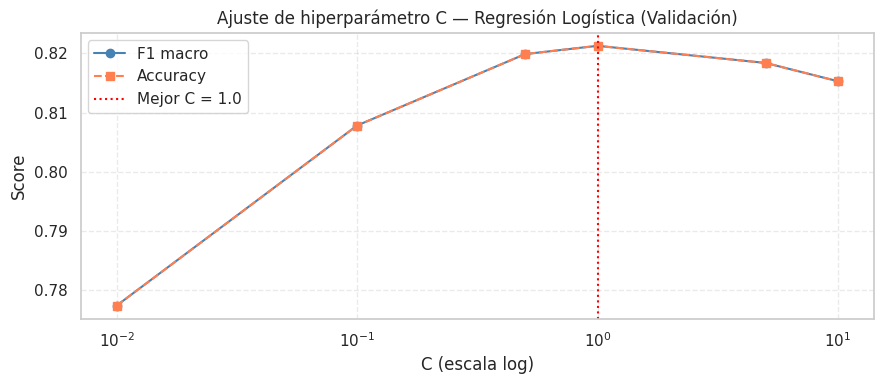

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_C['C'], df_C['f1_macro'],  marker='o', color='steelblue', label='F1 macro')
ax.plot(df_C['C'], df_C['accuracy'],  marker='s', color='coral',     label='Accuracy', linestyle='--')
ax.axvline(x=best_C, color='red', linestyle=':', linewidth=1.5, label=f'Mejor C = {best_C}')
ax.set_xscale('log')
ax.set_xlabel('C (escala log)')
ax.set_ylabel('Score')
ax.set_title('Ajuste de hiperparámetro C — Regresión Logística (Validación)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Entrenamiento Final

Con el mejor `C`, re-entrenamos con **todo** `X_train_tfidf` (1,360,000 filas).


In [ ]:
model_final = LogisticRegression(
    C=best_C,
    solver='saga',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1
)
model_final.fit(X_train_tfidf, y_train)
print(f'Modelo final entrenado: C={best_C}')
print(f'Docs de entrenamiento:  {X_train_tfidf.shape[0]:,}')
print(f'Features (n-gramas):    {X_train_tfidf.shape[1]:,}')


Modelo final entrenado: C=1.0
Docs de entrenamiento:  1,360,000
Features (n-gramas):    100,000


In [ ]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1_macro':  f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall':    recall_score(y_true, y_pred, average='macro'),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }


## 6. Evaluación Final en Test

Este es el **único momento** en que usamos `X_test_tfidf`.


In [ ]:
y_pred_test  = model_final.predict(X_test_tfidf)
y_proba_test = model_final.predict_proba(X_test_tfidf)[:, 1]
metrics_test = get_metrics(y_test, y_pred_test, y_proba_test)

y_pred_train  = model_final.predict(X_train_tfidf)
y_proba_train = model_final.predict_proba(X_train_tfidf)[:, 1]
metrics_train = get_metrics(y_train, y_pred_train, y_proba_train)

y_pred_val_f  = model_final.predict(X_val)
y_proba_val_f = model_final.predict_proba(X_val)[:, 1]
metrics_val   = get_metrics(y_val, y_pred_val_f, y_proba_val_f)

print('=== EVALUACIÓN FINAL — Logistic Regression + TF-IDF Bigrama ===')
print(f'  Accuracy:  {metrics_test["accuracy"]:.4f}')
print(f'  F1 macro:  {metrics_test["f1_macro"]:.4f}')
print(f'  Precision: {metrics_test["precision"]:.4f}')
print(f'  Recall:    {metrics_test["recall"]:.4f}')
print(f'  ROC-AUC:   {metrics_test["roc_auc"]:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Negativo (0)', 'Positivo (1)']))


=== EVALUACIÓN FINAL — Logistic Regression + TF-IDF Bigrama ===
  Accuracy:  0.8232
  F1 macro:  0.8232
  Precision: 0.8234
  Recall:    0.8233
  ROC-AUC:   0.9025

              precision    recall  f1-score   support

Negativo (0)       0.83      0.81      0.82    120129
Positivo (1)       0.82      0.83      0.82    119871

    accuracy                           0.82    240000
   macro avg       0.82      0.82      0.82    240000
weighted avg       0.82      0.82      0.82    240000



### 6.1 Gráfica: Métricas Train / Val / Test

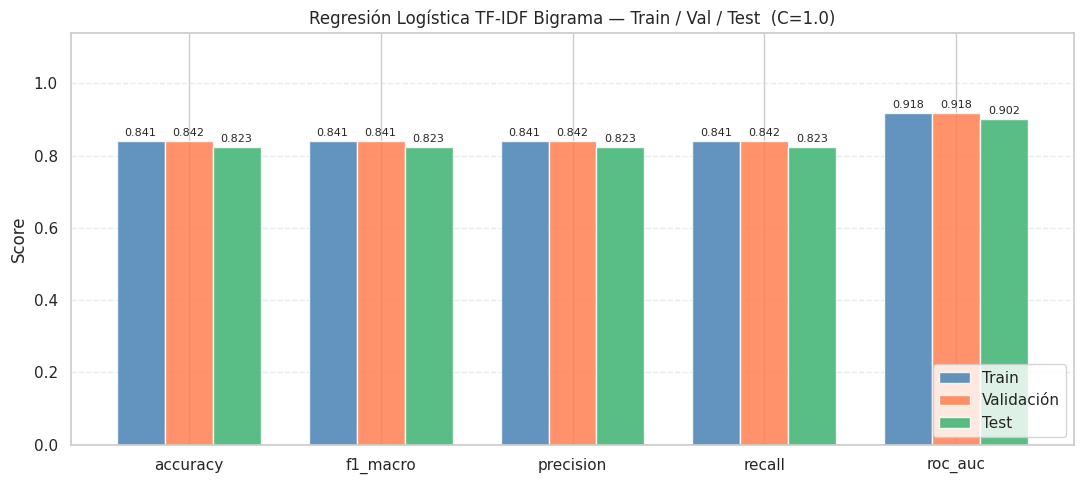

In [ ]:
metric_names = ['accuracy', 'f1_macro', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metric_names))
w = 0.25

vals_tr   = [metrics_train[m] for m in metric_names]
vals_val  = [metrics_val[m]   for m in metric_names]
vals_test = [metrics_test[m]  for m in metric_names]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, vals_tr,   w, label='Train',      color='steelblue',      alpha=0.85)
b2 = ax.bar(x,     vals_val,  w, label='Validación', color='coral',          alpha=0.85)
b3 = ax.bar(x + w, vals_test, w, label='Test',       color='mediumseagreen', alpha=0.85)

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.14)
ax.set_ylabel('Score')
ax.set_title(f'Regresión Logística TF-IDF Bigrama — Train / Val / Test  (C={best_C})')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 6.2 Matriz de Confusión — Test Final

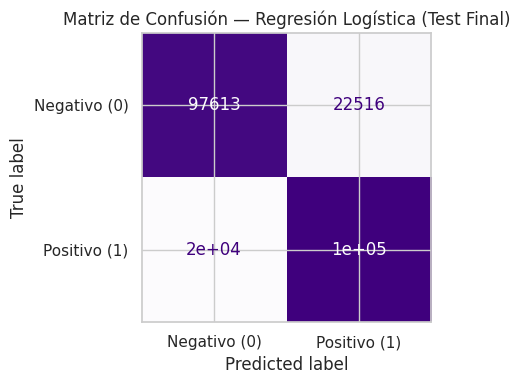

In [ ]:
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativo (0)', 'Positivo (1)'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Matriz de Confusión — Regresión Logística (Test Final)')
plt.tight_layout()
plt.show()


### 6.3 Top 20 features por peso del modelo

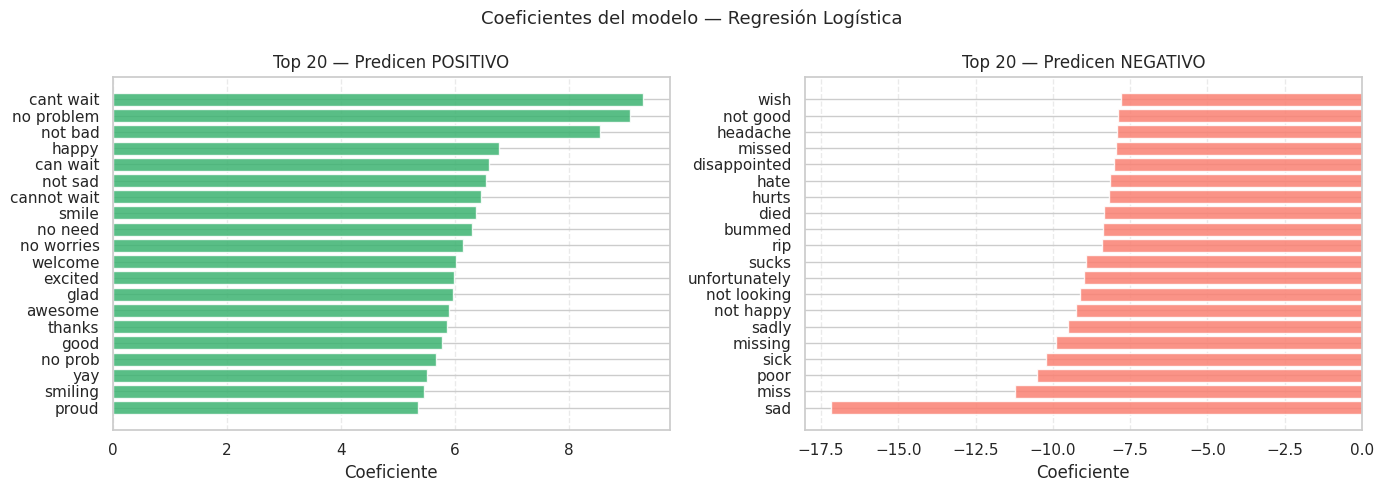

In [ ]:
vectorizer    = joblib.load('tfidf_vectorizer.pkl')
feature_names = vectorizer.get_feature_names_out()
coefs         = model_final.coef_[0]

top_pos_idx = np.argsort(coefs)[::-1][:20]   # más positivos
top_neg_idx = np.argsort(coefs)[:20]          # más negativos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1],
             color='mediumseagreen', alpha=0.85)
axes[0].set_title('Top 20 — Predicen POSITIVO')
axes[0].set_xlabel('Coeficiente')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx],
             color='salmon', alpha=0.85)
axes[1].set_title('Top 20 — Predicen NEGATIVO')
axes[1].set_xlabel('Coeficiente')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Coeficientes del modelo — Regresión Logística', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Guardar modelo y resultados

In [ ]:
joblib.dump(model_final, 'lr_tfidf_model.pkl')

results_final = pd.DataFrame([{
    'modelo':    'LogisticRegression',
    'encoding':  'TF-IDF Bigrama',
    'C':         best_C,
    'solver':    'saga',
    'train_acc': round(metrics_train['accuracy'],  4),
    'train_f1':  round(metrics_train['f1_macro'],  4),
    'train_auc': round(metrics_train['roc_auc'],   4),
    'val_acc':   round(metrics_val['accuracy'],    4),
    'val_f1':    round(metrics_val['f1_macro'],    4),
    'val_auc':   round(metrics_val['roc_auc'],     4),
    'test_acc':  round(metrics_test['accuracy'],   4),
    'test_f1':   round(metrics_test['f1_macro'],   4),
    'test_auc':  round(metrics_test['roc_auc'],    4),
}])

results_final.to_csv('results_lr.csv', index=False)
print('Guardados: lr_tfidf_model.pkl | results_lr.csv')
print()
print(results_final.T.to_string(header=False))


Guardados: lr_tfidf_model.pkl | results_lr.csv

modelo     LogisticRegression
encoding       TF-IDF Bigrama
C                         1.0
solver                   saga
train_acc               0.841
train_f1                0.841
train_auc              0.9182
val_acc                0.8415
val_f1                 0.8415
val_auc                0.9183
test_acc               0.8232
test_f1                0.8232
test_auc               0.9025


## 8. Predicción en Vivo

In [ ]:
import re

try: vectorizer
except NameError: vectorizer = joblib.load('tfidf_vectorizer.pkl')
try: model_final
except NameError: model_final = joblib.load('lr_tfidf_model.pkl')

def clean_raw_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ════════════════════════════════════════════════════
# ↓↓↓  CAMBIA ESTE TEXTO  ↓↓↓
texto = "I dont like eating cold food"
# ════════════════════════════════════════════════════

texto_limpio = clean_raw_text(texto)
X_input      = vectorizer.transform([texto_limpio])
pred         = model_final.predict(X_input)[0]
proba        = model_final.predict_proba(X_input)[0]

label     = '😊 Positivo' if pred == 1 else '😞 Negativo'
confianza = proba[pred]
barra     = '█' * int(confianza * 30) + '░' * (30 - int(confianza * 30))

print('─' * 50)
print(f'  Texto original : {texto}')
print(f'  Texto limpio   : {texto_limpio}')
print('─' * 50)
print(f'  Predicción     : {label}')
print(f'  Confianza      : {confianza:.1%}  {barra}')
print(f'  P(Negativo)    : {proba[0]:.4f}')
print(f'  P(Positivo)    : {proba[1]:.4f}')
print('─' * 50)


──────────────────────────────────────────────────
  Texto original : I dont like eating cold food
  Texto limpio   : I dont like eating cold food
──────────────────────────────────────────────────
  Predicción     : 😞 Negativo
  Confianza      : 93.5%  ████████████████████████████░░
  P(Negativo)    : 0.9347
  P(Positivo)    : 0.0653
──────────────────────────────────────────────────


## 9. Registro en MLflow

In [ ]:
mlflow.set_tracking_uri("http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
mlflow.set_experiment("Parcial_1_NLP")

with mlflow.start_run(run_name="LogisticRegression_TFIDFBigrama") as run:

    # ── Tags ──────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "user":       "Juan Camilo Gallardo",
        "model_type": "LogisticRegression",
        "encoding":   "TF-IDF Bigrama",
        "dataset":    "Sentiment140Twitter",
    })

    # ── Parámetros de preprocesamiento ────────────────────────────────────────
    mlflow.log_params({
        "prep_remove_urls":      True,
        "prep_remove_mentions":  True,
        "prep_remove_hashtags":  True,
        "prep_remove_emojis":    True,
        "prep_remove_stopwords": False,
        "prep_lemmatization":    False,
    })

    # ── Parámetros de codificación ────────────────────────────────────────────
    mlflow.log_params({
        "vec_type":         "TfidfVectorizer",
        "vec_max_features": 100000,
        "vec_min_df":       5,
        "vec_max_df":       0.95,
        "vec_ngram_range":  "(1,2)",
        "vec_sublinear_tf": True,
    })

    # ── Parámetros del modelo ─────────────────────────────────────────────────
    mlflow.log_params({
        "model":      "LogisticRegression",
        "C":          best_C,
        "solver":     "saga",
        "max_iter":   1000,
        "seed":       SEED,
        "train_size": X_train_tfidf.shape[0],
        "val_size":   X_val.shape[0],
        "test_size":  X_test_tfidf.shape[0],
        "vocab_size": X_train_tfidf.shape[1],
    })

    # ── Métricas Train ────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "train_accuracy":  round(metrics_train['accuracy'],  4),
        "train_f1_macro":  round(metrics_train['f1_macro'],  4),
        "train_precision": round(metrics_train['precision'], 4),
        "train_recall":    round(metrics_train['recall'],    4),
        "train_roc_auc":   round(metrics_train['roc_auc'],   4),
    })

    # ── Métricas Validación ───────────────────────────────────────────────────
    mlflow.log_metrics({
        "val_accuracy":    round(metrics_val['accuracy'],  4),
        "val_f1_macro":    round(metrics_val['f1_macro'],  4),
        "val_precision":   round(metrics_val['precision'], 4),
        "val_recall":      round(metrics_val['recall'],    4),
        "val_roc_auc":     round(metrics_val['roc_auc'],   4),
    })

    # ── Métricas Test ─────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "test_accuracy":   round(metrics_test['accuracy'],  4),
        "test_f1_macro":   round(metrics_test['f1_macro'],  4),
        "test_precision":  round(metrics_test['precision'], 4),
        "test_recall":     round(metrics_test['recall'],    4),
        "test_roc_auc":    round(metrics_test['roc_auc'],   4),
    })

    # ── Artefactos ────────────────────────────────────────────────────────────
    mlflow.log_artifact("results_lr.csv")
    mlflow.sklearn.log_model(model_final, artifact_path="model",
                             registered_model_name="LogisticRegression_TFIDFBigrama")

    print("=" * 55)
    print("  ✅ Run registrado en MLflow")
    print(f"  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
    print(f"  Experimento : Parcial_1_NLP")
    print(f"  Corrida     : LogisticRegression_TFIDFBigrama")
    print(f"  Run ID      : {run.info.run_id}")
    print(f"  Test F1     : {metrics_test['f1_macro']:.4f}")
    print(f"  Test AUC    : {metrics_test['roc_auc']:.4f}")
    print("=" * 55)


2026/03/09 18:03:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 18:03:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'LogisticRegression_TFIDFBigrama'.
2026/03/09 18:03:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LogisticRegression_TFIDFBigrama, version 1
Created version '1' of model 'LogisticRegression_TFIDFBigrama'.


  ✅ Run registrado en MLflow
  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000
  Experimento : Parcial_1_NLP
  Corrida     : LogisticRegression_TFIDFBigrama
  Run ID      : 141a91ec54fe4b7598a0d1be39257999
  Test F1     : 0.8232
  Test AUC    : 0.9025
🏃 View run LogisticRegression_TFIDFBigrama at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1/runs/141a91ec54fe4b7598a0d1be39257999
🧪 View experiment at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1
